In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load data
df = pd.read_csv("../AB_NYC_2019.csv")

In [3]:
# Initial Exploration
print(df.head())
print(df.shape)
print(df.columns)
print(df.describe())
# Check for missing values
print(df.isnull().sum())
# Imputation of missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["last_review"] = df["last_review"].fillna("No reviews")
# Remove rows with missing values in 'name' and 'host_name'
df = df.dropna(subset=["name", "host_name"])
# Checking for $0 price listings and removing $0 price listings
print(df[df["price"] == 0].T)
df = df[df["price"] > 0]
print(df["price"].describe())
# Cleaning price outliers with IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
print(upper)
df = df[df["price"] <= upper]
# Confirm cleaning
print(df.shape)
print(df.isnull().sum())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

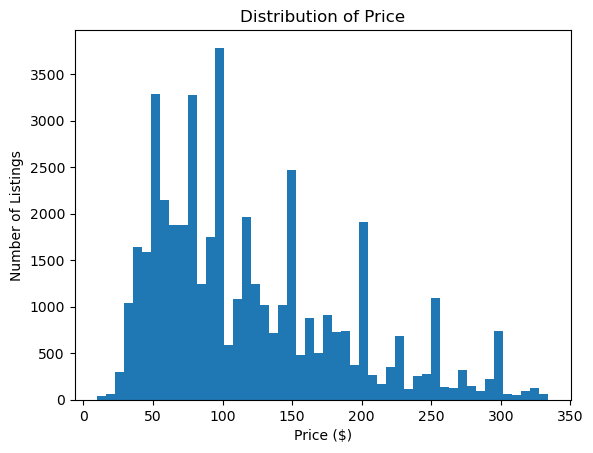

In [4]:
# EDA Visualization
plt.hist(df["price"], bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.show()

room_type
Entire home/apt    22772
Private room       21969
Shared room         1135
Name: count, dtype: int64
room_type
Entire home/apt    162.531398
Private room        79.047476
Shared room         59.335683
Name: price, dtype: float64


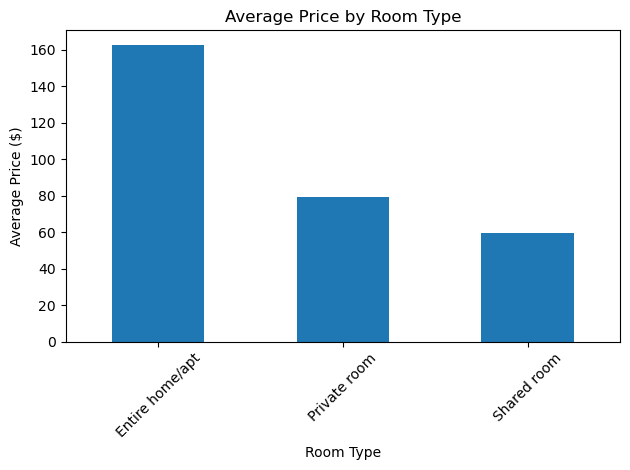

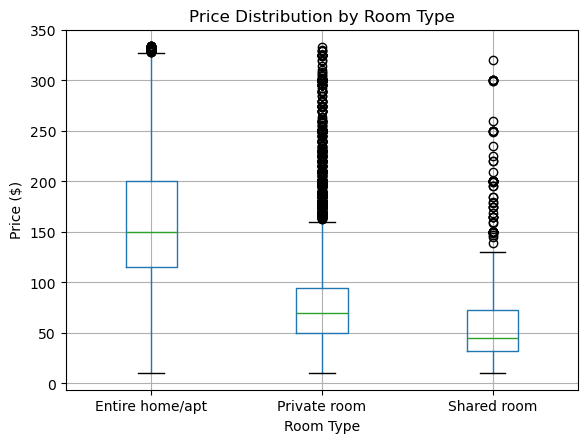

In [5]:
# EDA on categorical variables
print(df["room_type"].value_counts())
print(df.groupby("room_type")["price"].mean())
df.groupby("room_type")["price"].mean().plot(kind="bar")
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df.boxplot(column="price", by="room_type")
plt.title("Price Distribution by Room Type")
plt.suptitle("")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()

neighbourhood_group
Manhattan        19488
Brooklyn         19391
Queens            5565
Bronx             1067
Staten Island      365
Name: count, dtype: int64
neighbourhood_group
Bronx             77.390815
Brooklyn         105.762519
Manhattan        145.950380
Queens            88.919317
Staten Island     89.235616
Name: price, dtype: float64


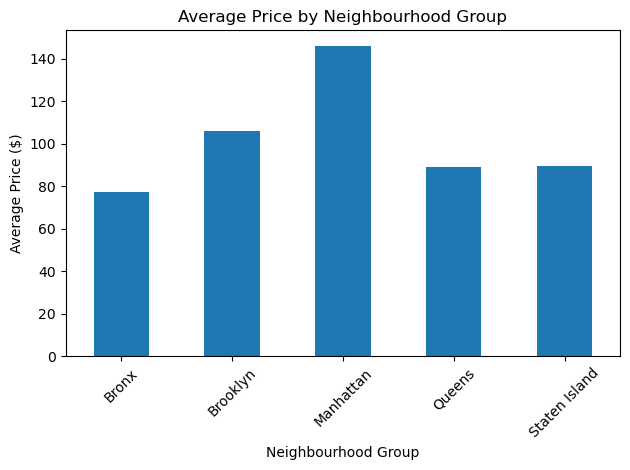

In [6]:
print(df["neighbourhood_group"].value_counts())
print(df.groupby("neighbourhood_group")["price"].mean())
df.groupby("neighbourhood_group")["price"].mean().plot(kind="bar")
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

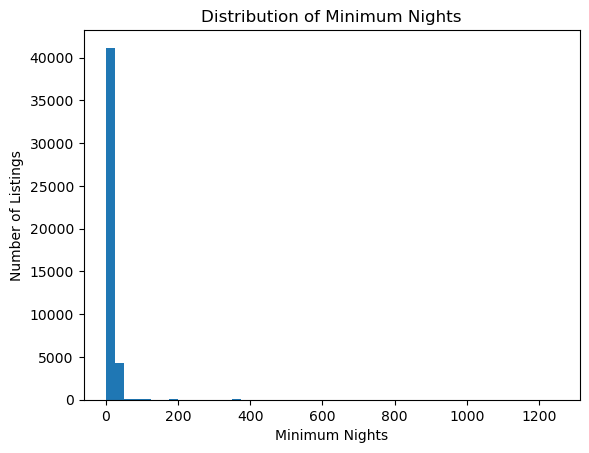

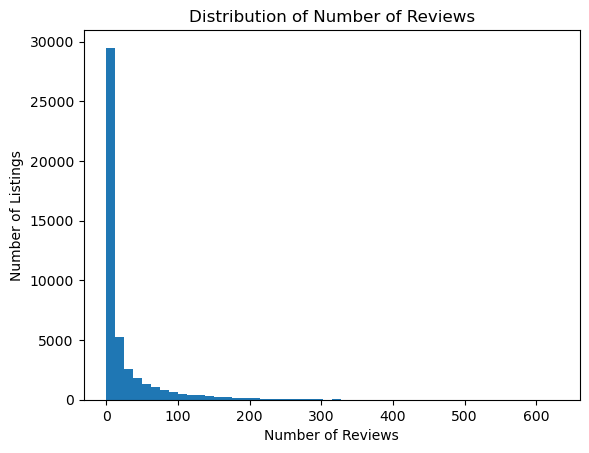

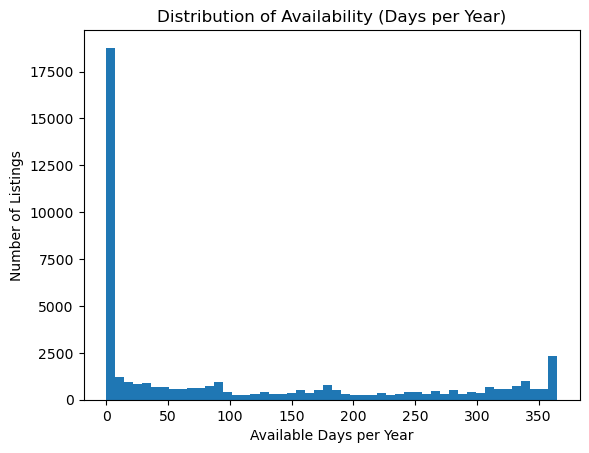

                      price  minimum_nights  number_of_reviews  \
price              1.000000        0.031493          -0.027592   
minimum_nights     0.031493        1.000000          -0.082895   
number_of_reviews -0.027592       -0.082895           1.000000   
availability_365   0.066777        0.146406           0.183354   

                   availability_365  
price                      0.066777  
minimum_nights             0.146406  
number_of_reviews          0.183354  
availability_365           1.000000  


In [7]:
# EDA on numeric variables
plt.hist(df["minimum_nights"], bins=50)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.show()

plt.hist(df["number_of_reviews"], bins=50)
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Listings")
plt.show()

plt.hist(df["availability_365"], bins=50)
plt.title("Distribution of Availability (Days per Year)")
plt.xlabel("Available Days per Year")
plt.ylabel("Number of Listings")
plt.show()

print(df[["price", "minimum_nights", "number_of_reviews", "availability_365"]].corr())

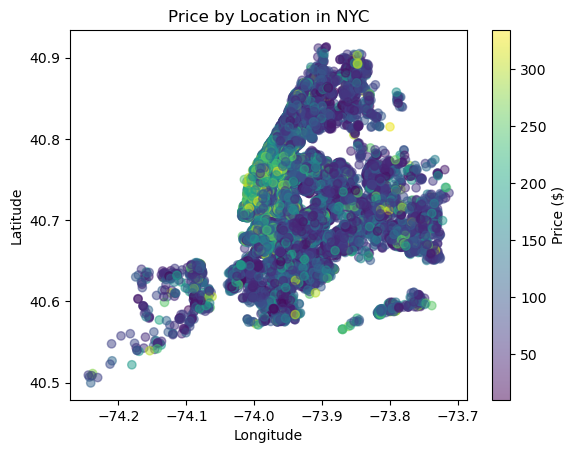

In [8]:
# Location Visualization
plt.scatter(df["longitude"], df["latitude"], c=df["price"], cmap="viridis", alpha=0.5)
plt.title("Price by Location in NYC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="Price ($)")
plt.show()

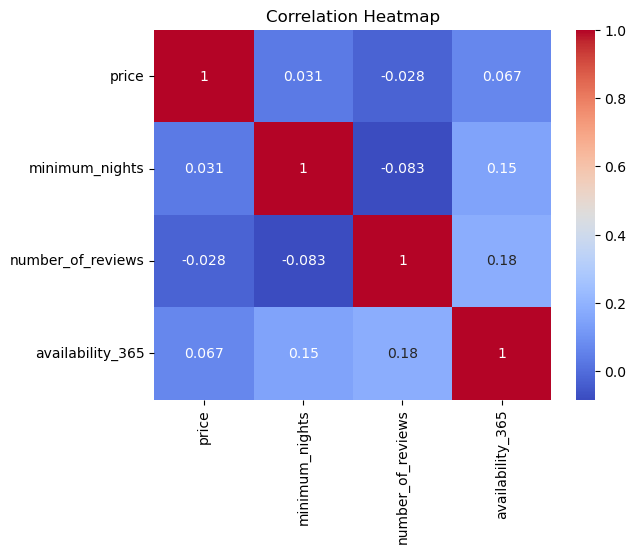

In [9]:
# Correlation heatmap
import seaborn as sns

sns.heatmap(
    df[["price", "minimum_nights", "number_of_reviews", "availability_365"]].corr(),
    annot=True,
    cmap="coolwarm",
)
plt.title("Correlation Heatmap")
plt.show()